In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from zipfile import ZipFile
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import MobileNetV2, DenseNet121
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

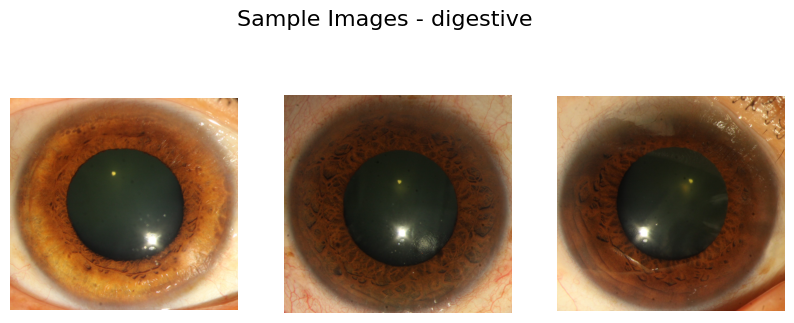

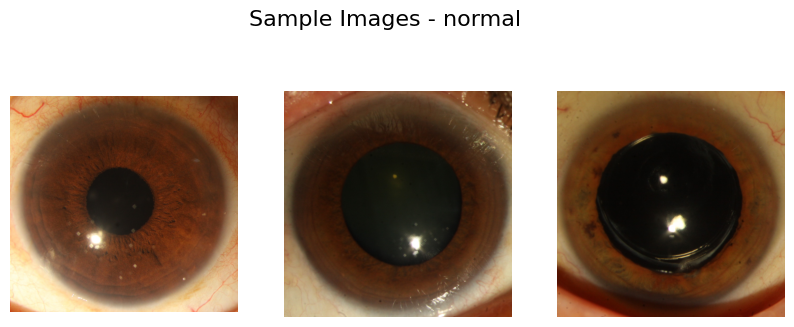

In [ ]:
path = '/content/drive/MyDrive/Research/New folder'
classes = ['digestive', 'normal']

# ==========================================
# 3. VISUALIZE SAMPLE IMAGES
# ==========================================
for cat in classes:
    image_dir = f'{path}/{cat}'
    images = os.listdir(image_dir)

    fig, ax = plt.subplots(1, 3, figsize=(10, 4))
    fig.suptitle(f'Sample Images - {cat}', fontsize=16)

    for i in range(3):
        img = np.array(Image.open(os.path.join(image_dir, images[np.random.randint(len(images))])))
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()


In [ ]:
# ==========================================
# 4. PARAMETERS
# ==========================================
IMG_SIZE = 256
BATCH_SIZE = 64
EPOCHS_PHASE1 = 20
EPOCHS_PHASE2 = 20
SPLIT = 0.2

# ==========================================
# 5. LOAD & PREPROCESS DATA
# ==========================================
X, Y = [], []

for i, cat in enumerate(classes):
    images = glob(f'{path}/{cat}/*.JPG')

    for image in images:
        img = cv2.imread(image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # IMPORTANT
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        Y.append(i)

X = np.array(X, dtype="float32")
Y = np.array(Y)

Y_cat = keras.utils.to_categorical(Y, num_classes=len(classes))

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y_cat, test_size=SPLIT, random_state=42, stratify=Y
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

Train: (124, 256, 256, 3), Validation: (32, 256, 256, 3)


In [ ]:
# ==========================================
# 6. CLASS WEIGHTS (OPTIONAL BUT RECOMMENDED)
# ==========================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y),
    y=Y
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [ ]:
# ==========================================
# 7. DATA AUGMENTATION
# ==========================================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augmentation")

In [ ]:
# ==========================================
# 8. HYBRID MODEL ARCHITECTURE
# ==========================================
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(input_layer)

# Preprocessing for each backbone
mobile_input = mobilenet_preprocess(x)
dense_input = densenet_preprocess(x)

# MobileNetV2 Branch
base_mobile = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_tensor=mobile_input
)
base_mobile.trainable = False
mobile_features = layers.GlobalAveragePooling2D()(base_mobile.output)

# DenseNet121 Branch
base_dense = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_tensor=dense_input
)
base_dense.trainable = False
dense_features = layers.GlobalAveragePooling2D()(base_dense.output)

# Feature Fusion
combined = layers.Concatenate()([mobile_features, dense_features])

# Classification Head
x = layers.Dense(512, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.6)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(len(classes), activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)
model.summary()

/tmp/ipython-input-1443476229.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobile = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 256, 256,  │          0 │ augmentation[0][… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ true_divide_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_2       │ (None, 256, 256,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ true_divide_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r

 Total params: 10,610,562 (40.48 MB)

 Trainable params: 1,313,538 (5.01 MB)

 Non-trainable params: 9,297,024 (35.47 MB)

In [ ]:
# ==========================================
# 9. COMPILE (PHASE 1)
# ==========================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [ ]:
# ==========================================
# 10. TRAINING – PHASE 1 (FEATURE EXTRACTION)
# ==========================================
history_1 = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS_PHASE1,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 87s 37s/step - accuracy: 0.4311 - loss: 1.3203 - val_accuracy: 0.5000 - val_loss: 0.8572
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 67s 27s/step - accuracy: 0.5691 - loss: 1.0926 - val_accuracy: 0.5000 - val_loss: 0.7501
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 83s 28s/step - accuracy: 0.6221 - loss: 0.9760 - val_accuracy: 0.5938 - val_loss: 0.6740
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 79s 28s/step - accuracy: 0.6119 - loss: 0.9868 - val_accuracy: 0.7500 - val_loss: 0.6088
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 49s 28s/step - accuracy: 0.6806 - loss: 0.8471 - val_accuracy: 0.8125 - val_loss: 0.5547
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 28s/step - accuracy: 0.6433 - loss: 0.8068 - val_accuracy: 0.8125 - val_loss: 0.5125
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 27s/step - accuracy: 0.7129 - loss: 0.7599 - val_accuracy: 0.8125 - val_loss: 0.4810
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 82s 28s/step - accuracy: 0.7181 - loss: 0.7590 - val_accuracy: 0.8125 - val_loss: 0.4585


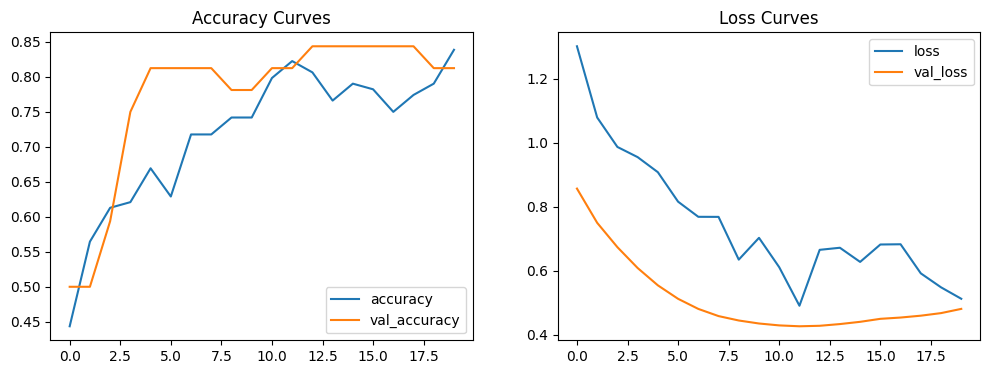

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step


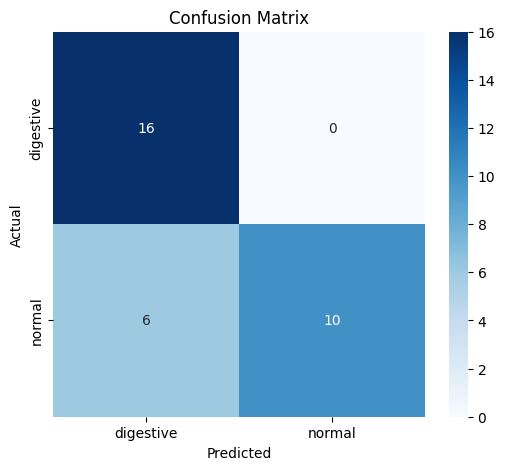

In [ ]:
# Plot Accuracy and Loss
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history_df = pd.DataFrame(history_1.history)

history_df[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title('Accuracy Curves')

history_df[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title('Loss Curves')
plt.show()

# Confusion Matrix
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# ==========================================
# 11. FINE-TUNING (PHASE 2)
# ==========================================
for layer in base_mobile.layers[-30:]:
    layer.trainable = True

for layer in base_dense.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_2 = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS_PHASE2,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 99s 37s/step - accuracy: 0.6598 - loss: 0.8379 - val_accuracy: 0.8125 - val_loss: 0.4850
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 70s 27s/step - accuracy: 0.6860 - loss: 0.8298 - val_accuracy: 0.8125 - val_loss: 0.4891
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 47s 28s/step - accuracy: 0.6915 - loss: 0.7982 - val_accuracy: 0.8125 - val_loss: 0.4934
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 48s 29s/step - accuracy: 0.7656 - loss: 0.6484 - val_accuracy: 0.8125 - val_loss: 0.4970
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 81s 28s/step - accuracy: 0.7233 - loss: 0.7835 - val_accuracy: 0.8125 - val_loss: 0.5007
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 49s 30s/step - accuracy: 0.6124 - loss: 0.8899 - val_accuracy: 0.8125 - val_loss: 0.5037
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 81s 29s/step - accuracy: 0.5906 - loss: 0.9850 - val_accuracy: 0.8125 - val_loss: 0.5068
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 82s 28s/step - accuracy: 0.6915 - loss: 0.8381 - val_accuracy: 0.8125 - val_loss: 0.5108


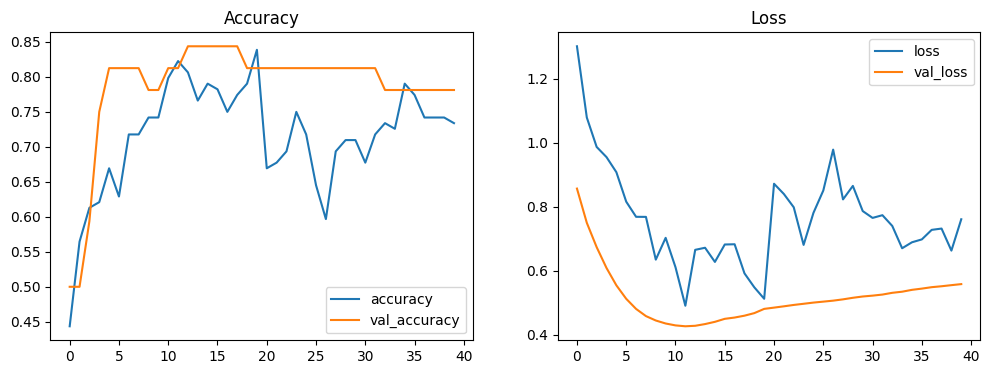

In [ ]:
# ==========================================
# 12. TRAINING CURVES
# ==========================================
history = pd.concat([
    pd.DataFrame(history_1.history),
    pd.DataFrame(history_2.history)
], ignore_index=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title("Accuracy")

history[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title("Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
              precision    recall  f1-score   support

   digestive       0.70      1.00      0.82        16
      normal       1.00      0.56      0.72        16

    accuracy                           0.78        32
   macro avg       0.85      0.78      0.77        32
weighted avg       0.85      0.78      0.77        32



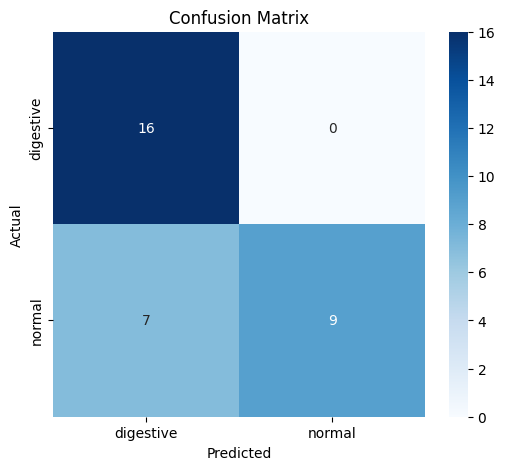

In [ ]:
# ==========================================
# 13. EVALUATION
# ==========================================
Y_pred = model.predict(X_val)
Y_pred_cls = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

print(classification_report(Y_true, Y_pred_cls, target_names=classes))

cm = confusion_matrix(Y_true, Y_pred_cls)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()